In [2]:
# use gmos filter curve, detected spectral type, and magnitude with Spextra to get the simulated flux

from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np


In [3]:
# import
oiii_hdu = fits.open("images/normalized_OIII.fits")
oiiic_hdu = fits.open("images/normalized_OIIIC.fits")
wcs_hdul = fits.open("images/SNR_OIII.fits")

# images
oiii_image = oiii_hdu[0].data
oiiic_image = oiii_hdu[0].data

# image headers
oiii_header = oiii_hdu[0].header
oiiic_header = oiiic_hdu[0].header

# create WCS
wcs = WCS(wcs_hdul["SCI"].header)

wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 86.9519162984652 -70.4145638364921 
CRPIX : 1567.851522483014 1069.07832988416 
CD1_1 CD1_2  : -1.1558431745326e-05 4.30113955981334e-05 
CD2_1 CD2_2  : -4.291815952434e-05 -1.1548898773803e-05 
NAXIS : 3164  2175

In [12]:
# identify a star in the image first
import numpy as np
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from astropy.nddata import Cutout2D

# OIII stats
mean, median, std = sigma_clipped_stats(oiii_image)
print(np.array((mean, median, std)))

# create a list of detected sources
daofind = DAOStarFinder(fwhm=7.0, threshold=5*std, roundlo=-0.2, roundhi=0.2)
sources_oiii = daofind(oiii_image - median)

# get the brightest star for now
brightest = sources_oiii[np.argmax(sources_oiii["flux"])]

[0.03193856 0.03825495 0.02422652]


In [14]:
# I should just try querying the one star with gaia first
# then take the temp and mag and scale

x = brightest["x_centroid"]
y = brightest["y_centroid"]
coord = wcs.pixel_to_world(x, y)

from astroquery.gaia import Gaia

radius = 2 / 3600  # 2 arsec in deg units

# query = f"""
# SELECT TOP 1 source_id, ra, dec, phot_bp_mean_mag, teff_gspphot, spectraltype_esphs
# FROM gaiadr3.gaiadr3astrophysical_parameters USING (source_id)
# INNER JOIN gaiadr3.astrophysical_parameters
# WHERE 1 = CONTAINS(POINT('ICRS', ra, dec),
#     CIRCLE('ICRS', {coord.ra.deg}, {coord.dec.deg}, {radius}))
# """


query = f"""
SELECT TOP 1
    g.source_id,
    g.ra,
    g.dec,
    g.phot_bp_mean_mag,
    ap.teff_gspphot,
    ap.spectraltype_esphs
FROM gaiadr3.gaia_source AS g
LEFT OUTER JOIN gaiadr3.astrophysical_parameters AS ap
    ON g.source_id = ap.source_id
WHERE 1 = CONTAINS(
    POINT('ICRS', g.ra, g.dec),
    CIRCLE(
        'ICRS',
        {coord.ra.deg},
        {coord.dec.deg},
        {radius}
    )
)
"""


job = Gaia.launch_job(query)
result = job.get_results()

print(result.columns)

df = result.to_pandas()
df

<TableColumns names=('SOURCE_ID','ra','dec','phot_bp_mean_mag','teff_gspphot','spectraltype_esphs')>


,SOURCE_ID,ra,dec,phot_bp_mean_mag,teff_gspphot,spectraltype_esphs
0,4656999405200489984,86.941278,-70.398233,13.614061,5709.821777,F


In [11]:
query = "SELECT TOP 5 * FROM gaiadr3.astrophysical_parameters"
job = Gaia.launch_job(query)
result = job.get_results()
print(result.colnames)

['solution_id', 'SOURCE_ID', 'classprob_dsc_combmod_quasar', 'classprob_dsc_combmod_galaxy', 'classprob_dsc_combmod_star', 'classprob_dsc_combmod_whitedwarf', 'classprob_dsc_combmod_binarystar', 'classprob_dsc_specmod_quasar', 'classprob_dsc_specmod_galaxy', 'classprob_dsc_specmod_star', 'classprob_dsc_specmod_whitedwarf', 'classprob_dsc_specmod_binarystar', 'classprob_dsc_allosmod_quasar', 'classprob_dsc_allosmod_galaxy', 'classprob_dsc_allosmod_star', 'teff_gspphot', 'teff_gspphot_lower', 'teff_gspphot_upper', 'logg_gspphot', 'logg_gspphot_lower', 'logg_gspphot_upper', 'mh_gspphot', 'mh_gspphot_lower', 'mh_gspphot_upper', 'distance_gspphot', 'distance_gspphot_lower', 'distance_gspphot_upper', 'azero_gspphot', 'azero_gspphot_lower', 'azero_gspphot_upper', 'ag_gspphot', 'ag_gspphot_lower', 'ag_gspphot_upper', 'abp_gspphot', 'abp_gspphot_lower', 'abp_gspphot_upper', 'arp_gspphot', 'arp_gspphot_lower', 'arp_gspphot_upper', 'ebpminrp_gspphot', 'ebpminrp_gspphot_lower', 'ebpminrp_gspphot_u

In [222]:
# make the gaia filter first
gaia_edr3 = np.loadtxt("filters/passband.dat")

wl = gaia_edr3[:, 0]   # wavelength in nm
bp = gaia_edr3[:, 3]   # transmission in BP

mask = bp != 99.99  # these are undefined values

wl = wl[mask]
bp = bp[mask]

np.savetxt("filters/gaia_bp.dat", np.column_stack((wl, bp)), header="Wavelength(nm) BP Transmission")


In [ ]:
# # make the gemini filter now
# oiii_filter = np.loadtxt("filters/gmos_s_OIII_G0338_jun2017.txt")

# wl = oiii_filter[:, 0]   # wavelength in nm
# t = oiii_filter[:, 1]   # transmission in BP

# np.savetxt("filters/gmos_oiii.dat", np.column_stack((wl, t)), header="Wavelength(nm) Transmission")


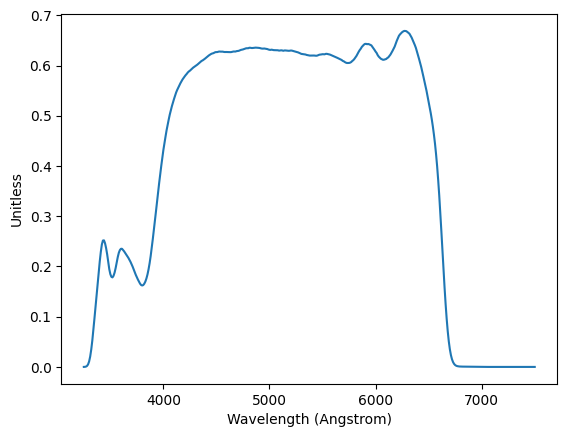

In [16]:
# using Synphot now
from synphot import SpectralElement
gaia_bp = SpectralElement.from_file("filters/gaia_bp.dat", wave_unit=u.nm)
gaia_bp.plot()

waves_aa = gaia_bp.waveset.to(u.AA)

gaia_bp.to_fits("filters/gaia_bp.fits", wavelengths=waves_aa, overwrite=True)  # for future use

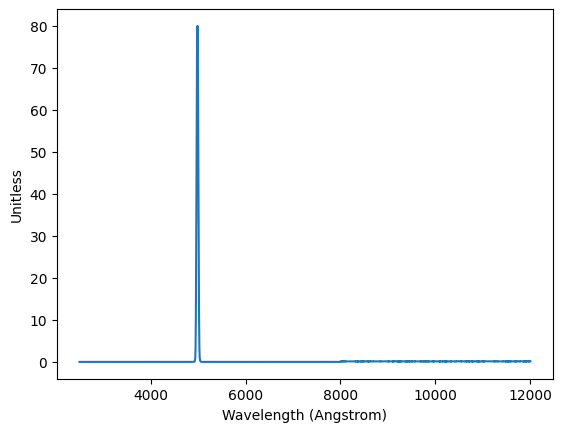

In [17]:
# using Synphot now
from synphot import SpectralElement
gmos_oiii = SpectralElement.from_file("filters/gmos_s_OIII_G0338_jun2017.txt", wave_unit=u.nm)
gmos_oiii.plot()

waves_aa = gmos_oiii.waveset.to(u.AA)

gmos_oiii.to_fits("filters/gmos_oiii.fits", wavelengths=waves_aa, overwrite=True) # for future use

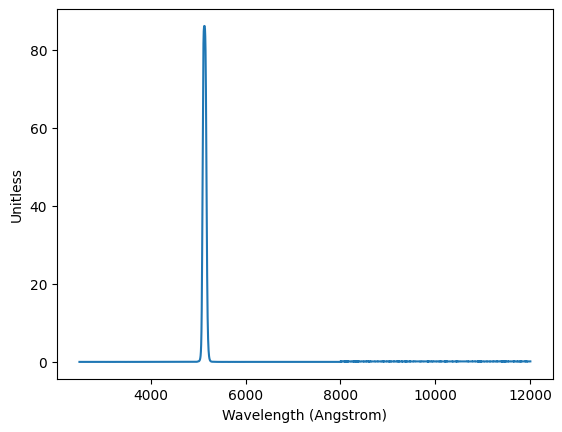

In [18]:
# using Synphot now
from synphot import SpectralElement
gmos_oiiic = SpectralElement.from_file("filters/gmos_s_OIIIC_G0339_jun2017.txt", wave_unit=u.nm)
gmos_oiiic.plot()

waves_aa = gmos_oiiic.waveset.to(u.AA)

gmos_oiiic.to_fits("filters/gmos_oiiic.fits", wavelengths=waves_aa, overwrite=True) # for future use

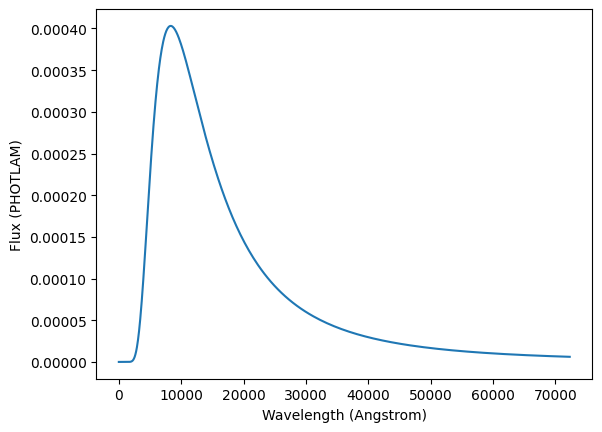

In [213]:
from synphot import SourceSpectrum, BlackBodyNorm1D
bb = SourceSpectrum(BlackBodyNorm1D, temperature=4407.522949)
bb.plot()

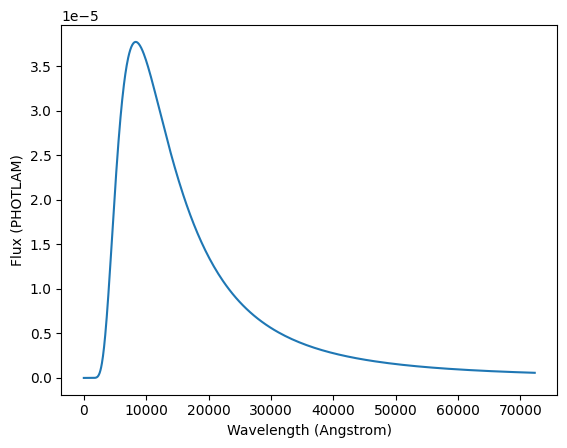

In [214]:
ab_mag = 19.230339 + (25.3539555559 - 25.3385422158)
bb_scaled = bb.normalize(19.230339*u.ABmag, band=gaia_bp)

bb_scaled.plot()

In [ ]:
from synphot import Observation

obs = Observation(bb_scaled, gmos_oiii)
flux = obs.integrate()
print(flux)

0.08246419535266582 ph / (s cm2)


In [232]:
photon_flux = obs.integrate()         # ph / (s cm2)
electron_rate = brightest["flux"]     # e- / s, if DAO flux really is total source rate

K_photon = photon_flux / electron_rate

print(K_photon)

print(electron_rate)

0.009351714781393133 ph / (s cm2)
8.818083
